<a href="https://colab.research.google.com/github/Korobokkk/Kiselev_I_dsp-seminars/blob/kiselev_lab_3/KieselevIseminars/3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №3

## Свёртка и корреляционный анализ сигналов

## Цели занятия
- Освоить вычисление свёртки и корреляции в Python.
- Применить свёртку для фильтрации сигналов.
- Использовать кросс-корреляцию для поиска временной задержки и обнаружения шаблона.
- Проанализировать влияние уровня шума на точность оценок.

## Подготовка окружения

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from IPython.display import Audio, display
import time

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)

## Задание 1. Свёртка гауссовых функций: сравнение численного и аналитического результатов

### Теоретическое введение
Свёртка двух гауссовых функций даёт гауссову функцию с дисперсией, равной сумме дисперсий. Если
$$
f(t) = \frac{1}{\sqrt{2\pi\sigma_1^2}} e^{-t^2/(2\sigma_1^2)}, \quad g(t) = \frac{1}{\sqrt{2\pi\sigma_2^2}} e^{-t^2/(2\sigma_2^2)},
$$
то
$$
(f * g)(t) = \frac{1}{\sqrt{2\pi(\sigma_1^2+\sigma_2^2)}} e^{-t^2/(2(\sigma_1^2+\sigma_2^2))}.
$$

### Задание
1. Сгенерируйте дискретные гауссовы импульсы (например, с помощью `scipy.signal.windows.gaussian`) с заданными стандартными отклонениями `sigma1=3`, `sigma2=5`. Используйте длину окна, достаточную для захвата всей значимой части (например, 10*sigma).
2. Вычислите свёртку численно с помощью `np.convolve`.
3. Постройте графики:
   - Исходные функции.
   - Результат свёртки (численный).
   - Теоретическую гауссову функцию с дисперсией `sigma1^2 + sigma2^2`.
4. Оцените среднеквадратичную ошибку между численным и теоретическим результатами.

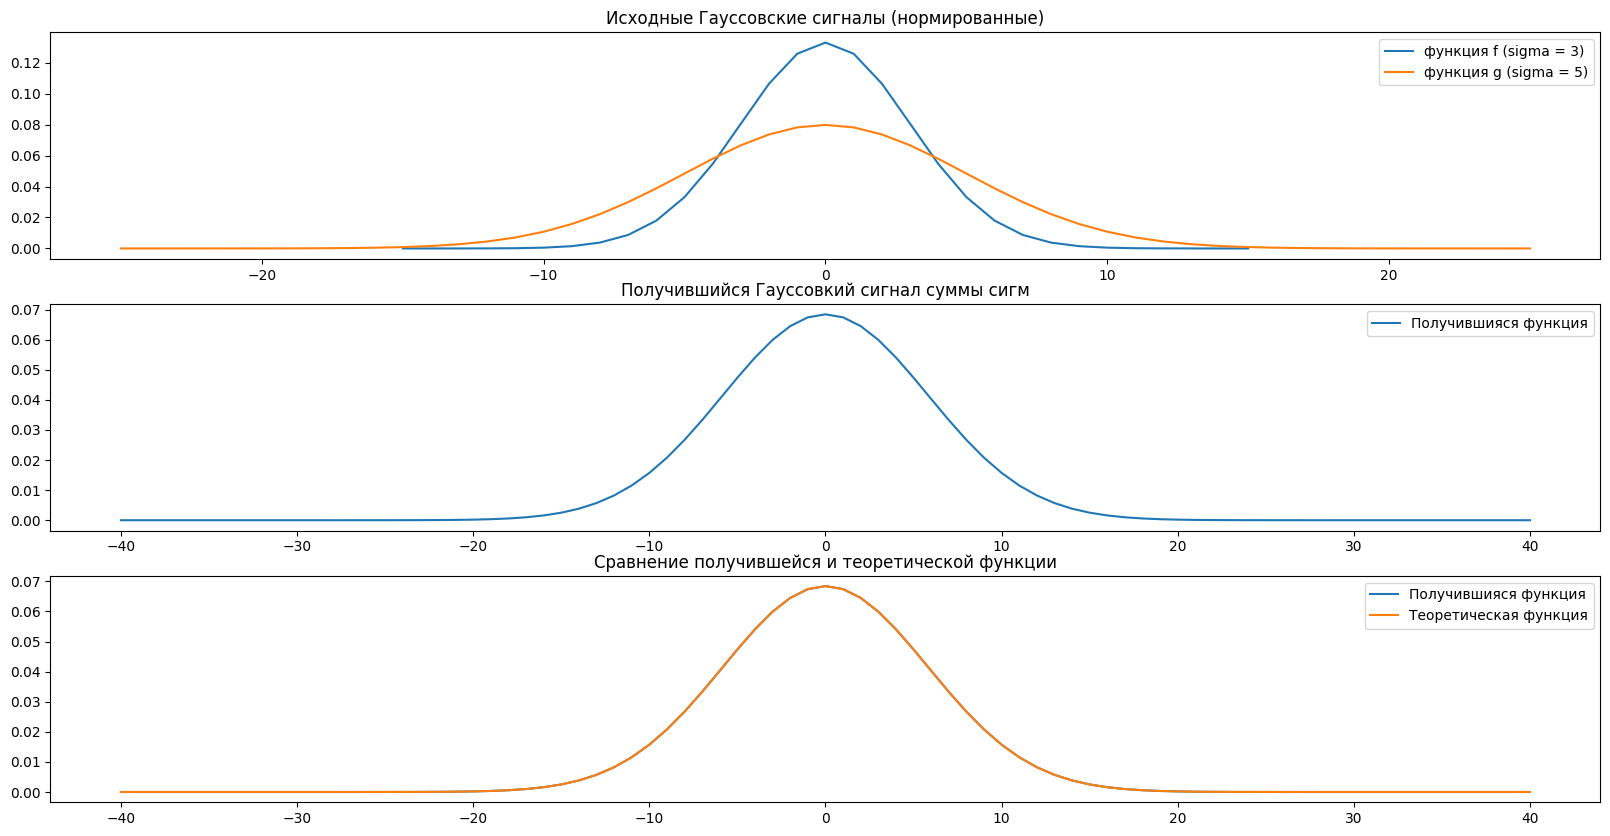

Средняя квадратическая ошибка = 2.4174613887108043e-16


In [16]:
sigma1 = 3
sigma2 = 5

M1 = 10 * sigma1 + 1
M2 = 10 * sigma2 + 1

f = signal.windows.gaussian(M1, sigma1)
g = signal.windows.gaussian(M2, sigma2)

f /= np.sum(f)
g /= np.sum(g)

f_res = np.convolve(f, g, mode='full')

disp_teor = sigma1 ** 2 + sigma2 ** 2
M3 = np.arange(M1 + M2 - 1) - (M1 + M2 - 1) // 2
f_teor = np.exp(-M3**2 / (2 * disp_teor))
f_teor /= np.sum(f_teor)
# print (f)
# print (g)
# print (M1)
# print (M2)
# print (len(f_res))
#print (len(f_teor))

t1 = np.arange(M1) - M1 // 2 # Адаптировал сдвиг по примеру Егашина Кирилла
t2 = np.arange(M2) - M2 // 2
t3 = np.arange(M1 + M2 - 1) - (M1 + M2 - 1) // 2

plt.figure(figsize=(20, 10))
plt.subplot(3, 1, 1)
plt.plot(t1, f, label = 'функция f (sigma = 3)')
plt.plot(t2, g, label = 'функция g (sigma = 5)')
plt.title('Иcходные Гауссовские сигналы (нормированные)')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t3, f_res, label = 'Получившияся функция')
plt.title('Получившийся Гауссовкий сигнал суммы сигм')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t3, f_res, label = 'Получившияся функция')
plt.plot(M3, f_teor, label = 'Теоретическая функция')
plt.title('Сравнение получившейся и теоретической функции')
plt.legend()

plt.show()


mse = np.mean((f_teor - f_res) ** 2)
print(f'Средняя квадратическая ошибка = {mse}')


**Вопросы:**
- Что произойдёт с формой свёртки при увеличении σ?

При увеличении сигма амплитуда уменьшается. Как я понял, сигма растягивает значение функции по времени, а поскольку при наличии нормировки сумма значений должна оставаться постоянной, получаемая функция будет терять амплитуду. Можно отдельно отметить, что функция сглаживается(что вытекает, из вышенаписанного).

## Задание 2. Фильтрация с помощью свёртки: сравнение прямоугольного и гауссовского окон

### Цель
Изучить, как выбор ядра и его длина влияют на подавление высокочастотной составляющей и сохранение низкочастотной.

### Задание
1. Создайте сигнал длительностью 2 секунды, частота дискретизации 1000 Гц, состоящий из суммы двух синусоид:
   - низкая частота \( f_1 = 5 \) Гц, амплитуда 1,
   - высокая частота \( f_2 = 80 \) Гц, амплитуда 0.5.
2. Сгенерируйте прямоугольное окно длины `L` (например, `L = 21`, используйте `scipy.signal.windows.boxcar(L)`), нормализованное так, чтобы сумма коэффициентов была 1.
3. Сгенерируйте гауссовское окно той же длины (используйте `signal.windows.gaussian(L, std=L/5)`), также нормализованное.
4. Примените свёртку с этими окнами (используйте `mode='same'`).
5. Постройте графики:
   - Исходный сигнал (первые 0.5 с).
   - Отфильтрованные сигналы для обоих окон.
6. Вычислите и сравните амплитуды полезной составляющей (5 Гц) и подавленной (80 Гц) после фильтрации. Для этого:
   - Возьмите БПФ сигналов,
   - Измерьте амплитуды на соответствующих частотах.
7. Исследуйте влияние длины окна: повторите для длин `L = 11, 21, 41, 81`.

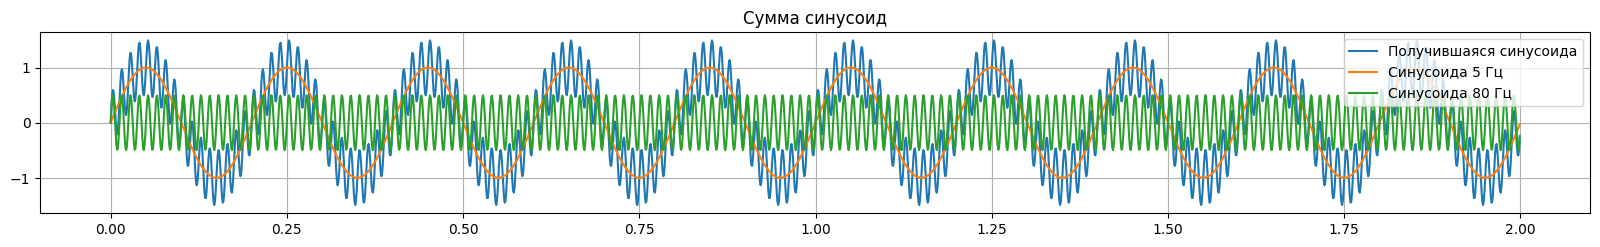

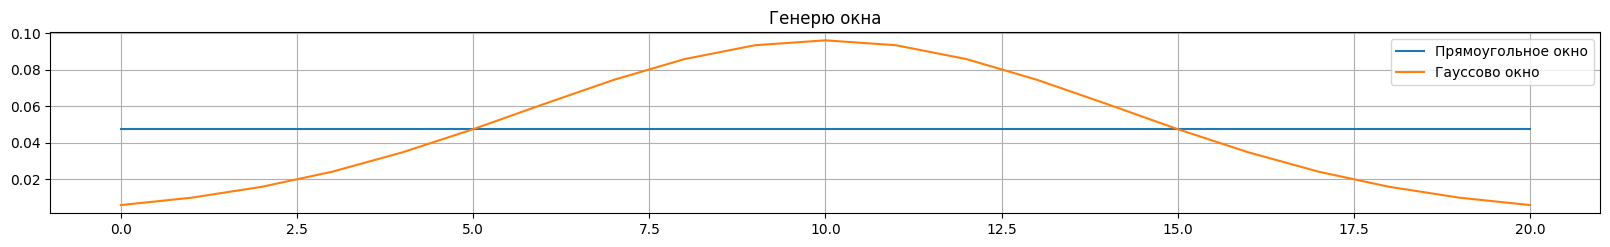

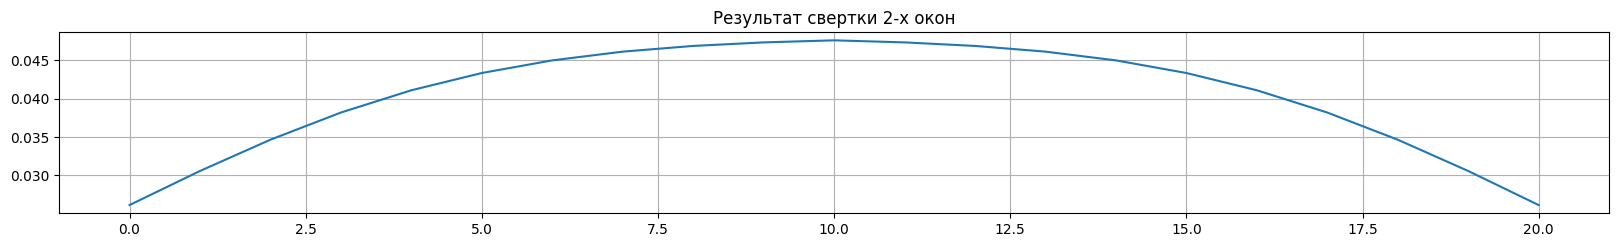

Графики:


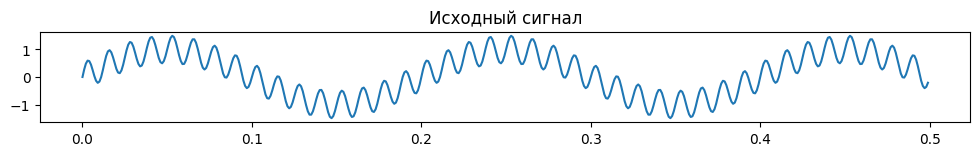

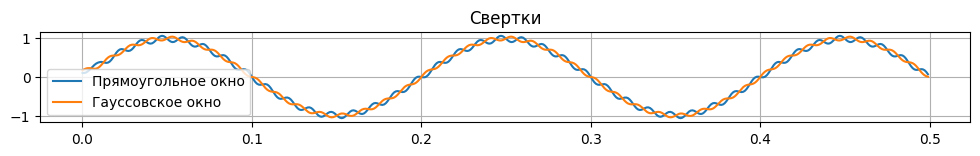

Амплитуды:
Исходный: 5 Гц  1.0000000000000002  80 Гц  0.5000000000000001
Прямоугольное окно 5 Гц 0.9822037371641048  80 Гц  0.08001922202135855
Гаусс: 5 Гц 0.9921720833678593  80 Гц  0.05024808866079134

Амплитуды: При L = 11
    Прямоугольное окно 5 Гц 0.9951180304402126  80 Гц  0.06784307173676588
    Гаусс: 5 Гц 0.9978351903016299  80 Гц  0.28035786104198696
Амплитуды: При L = 21
    Прямоугольное окно 5 Гц 0.9822037371641048  80 Гц  0.08001922202135855
    Гаусс: 5 Гц 0.9921720833678593  80 Гц  0.05024808866079134
Амплитуды: При L = 41
    Прямоугольное окно 5 Гц 0.9329659724321587  80 Гц  0.036658190959668595
    Гаусс: 5 Гц 0.9704476412925049  80 Гц  0.0004625880778065383
Амплитуды: При L = 81
    Прямоугольное окно 5 Гц 0.7542222147215227  80 Гц  0.025395283068249386
    Гаусс: 5 Гц 0.889099852192386  80 Гц  0.002753999617621469


In [17]:
f_1 = 5
A_1 = 1
f_2 = 80
A_2 = 0.5

fs = 1000
time = np.arange(0, 2, 1/fs)

sin_1 = A_1 * np.sin(2 * np.pi * f_1 * time)
sin_2 = A_2 * np.sin(2 * np.pi * f_2 * time)
result_signal = sin_1 + sin_2

plt.figure(figsize = (20,8))

plt.subplot(3, 1, 1)
plt.title('Сумма синусоид')
plt.plot(time, result_signal, label = 'Получившаяся синусоида')
plt.plot(time, sin_1, label = 'Синусоида 5 Гц')
plt.plot(time, sin_2, label = 'Синусоида 80 Гц')
plt.xlim=(0, 2)
plt.grid(True)
plt.legend()
plt.show()


L = 21
h_window = signal.windows.boxcar(L)/L

std = L/5
gauss_window = signal.windows.gaussian(L, std)
gauss_window/=np.sum(gauss_window)

plt.figure(figsize = (20,8))
plt.subplot(3, 1, 2)
plt.title('Генерю окна')
plt.plot(np.arange(L), h_window, label = 'Прямоугольное окно')
plt.plot(np.arange(L), gauss_window, label = 'Гауссово окно')
plt.legend()
plt.grid(True)
plt.xlim = (0, 20)
plt.show()

#print(len(gauss_window))
#print(h)
conv = np.convolve(h_window, gauss_window, mode='same')

plt.figure(figsize = (20,8))
plt.subplot(3, 1, 3)
plt.title('Результат свертки 2-х окон')
plt.plot(np.arange(L), conv)
plt.xlim= (0, 20)
plt.grid(True)
plt.show()


h_res_signal = np.convolve(result_signal, h_window, mode = 'same')
gauss_res_signal = np.convolve(result_signal, gauss_window, mode = 'same')
# print(len(h_res_signal))
# print(len(gauss_res_signal))

print('Графики:')
plt.subplot(3, 1, 1)
plt.title('Исходный сигнал')
plt.plot(time[:500], result_signal[:500])
plt.show()

plt.subplot(3, 1, 2)
plt.title('Свертки')
plt.plot(time[:500], h_res_signal[:500], label = 'Прямоугольное окно')
plt.plot(time[:500], gauss_res_signal[:500], label = 'Гауссовское окно')
plt.legend()
plt.grid(True)
plt.show()


def get_spectrum(signal, fs):
    N = len(signal)
    X = np.fft.fft(signal)
    freq = np.fft.fftfreq(N, d=1/fs)

    half = N // 2
    return freq[:half], 2 * np.abs(X[:half]) / N

freq_pos, X_mag_orig = get_spectrum(result_signal, fs)
freq_pos_rect, X_mag_rect = get_spectrum(h_res_signal, fs)
freq_pos_gauss, X_mag_gauss = get_spectrum(gauss_res_signal, fs)

idx_5 = np.argmin(np.abs(freq_pos - 5))
idx_80 = np.argmin(np.abs(freq_pos - 80))

idx_5_h = np.argmin(np.abs(freq_pos_rect - 5))
idx_80_h = np.argmin(np.abs(freq_pos_rect - 80))

idx_5_g = np.argmin(np.abs(freq_pos_gauss - 5))
idx_80_g = np.argmin(np.abs(freq_pos_gauss - 80))

print("Амплитуды:")
print("Исходный: 5 Гц ",  X_mag_orig[idx_5], " 80 Гц ", X_mag_orig[idx_80])
print("Прямоугольное окно 5 Гц", X_mag_rect[idx_5], " 80 Гц ", X_mag_rect[idx_80])
print("Гаусс: 5 Гц", X_mag_gauss[idx_5], " 80 Гц ", X_mag_gauss[idx_80])
print('')


L_arr = [11, 21, 41, 81]
for i in L_arr:
  h_window = signal.windows.boxcar(i)/ i

  std = i/5
  gauss_window = signal.windows.gaussian(i, std)
  gauss_window/=np.sum(gauss_window)

  h_res_signal = np.convolve(result_signal, h_window, mode = 'same')
  gauss_res_signal = np.convolve(result_signal, gauss_window, mode = 'same')

  freq_pos, X_mag_orig = get_spectrum(result_signal, fs)
  freq_pos_rect, X_mag_rect = get_spectrum(h_res_signal, fs)
  freq_pos_gauss, X_mag_gauss = get_spectrum(gauss_res_signal, fs)

  idx_5 = np.argmin(np.abs(freq_pos - 5))
  idx_80 = np.argmin(np.abs(freq_pos - 80))

  idx_5_h = np.argmin(np.abs(freq_pos_rect - 5))
  idx_80_h = np.argmin(np.abs(freq_pos_rect - 80))

  idx_5_g = np.argmin(np.abs(freq_pos_gauss - 5))
  idx_80_g = np.argmin(np.abs(freq_pos_gauss - 80))

  print(f"Амплитуды: При L = {i}")
  print("    Прямоугольное окно 5 Гц", X_mag_rect[idx_5], " 80 Гц ", X_mag_rect[idx_80])
  print("    Гаусс: 5 Гц", X_mag_gauss[idx_5], " 80 Гц ", X_mag_gauss[idx_80])


**Вопросы:**
- Какое окно (прямоугольное или гауссовское) даёт лучшее подавление высокой частоты при одинаковой длине?
- При какой длине прямоугольного и гауссовского окон амплитуда высокочастотного амплитуда падает в 10 раз?
- Как увеличение длины окна влияет на подавление сохранение амплитуды низкой частоты? При какой длине окон она уменьшается более чем на 10%?

1. При малых L прямоугольное окно дает лучшее подавление высокой частоты, при одинаковой длине. Начиная с L=21 и болеее (при моих вводных) Гауссовское окно дает лучшее подавление высоких частот.
2. Для прямоугольного окна начиная с L= 41 и более амплитуда высокочастотных сигналов падает в 10 раз. Для гауссовского окна, начиная с L=21 (при округлении 0.05024808866079134 до 0.05).
3. Для обоих окон амплитуда уменьшается более чем на 10% при L=81. При увеличении длины окна проявляется подавление амплитуд низких частот.

## Задание 3. Поиск временной задержки с помощью кросс-корреляции

### Цель
Определить временной сдвиг между двумя сигналами в присутствии шума и оценить влияние уровня шума на точность.

### Задание
1. Сгенерируйте сигнал длительностью 1 секунду (fs=1000 Гц), представляющий собой сумму 100 синусоид со случайными частотами (в диапазоне 10–100 Гц), амплитудами (в диапазоне 0.5–1.5 Гц) и фазами (в диапазоне 0–2$\pi$). Воспользуйтесь функцией `numpy.random.uniform`. Нормализуйте полученный сигнал в интервале $[-1;1]$. Назовём его `x`.
2. Создайте второй сигнал `y`, который является сдвинутой во времени копией `x` на `delay` отсчётов (выберите задержку, например, 100 отсчётов) и добавьте к нему случайный сигнал (шум) с уровнем `noise_level` (например, 0.1) с помощью функции `numpy.random.randn`.
3. Вычислите кросс-корреляцию `corr = np.correlate(x, y, mode='full')` и найдите индекс максимума. Оцените задержку как `delay_est = argmax(corr) - (len(x)-1)` (поскольку `mode='full'` даёт диапазон от -N+1 до N-1).
4. Повторите эксперимент для различных уровней шума в диапазоне от `0` до `2`.
5. Для двух уровней шума (0.3 и 2) постройте график кросс-корреляции и отметьте положение истинной и найденной задержки.

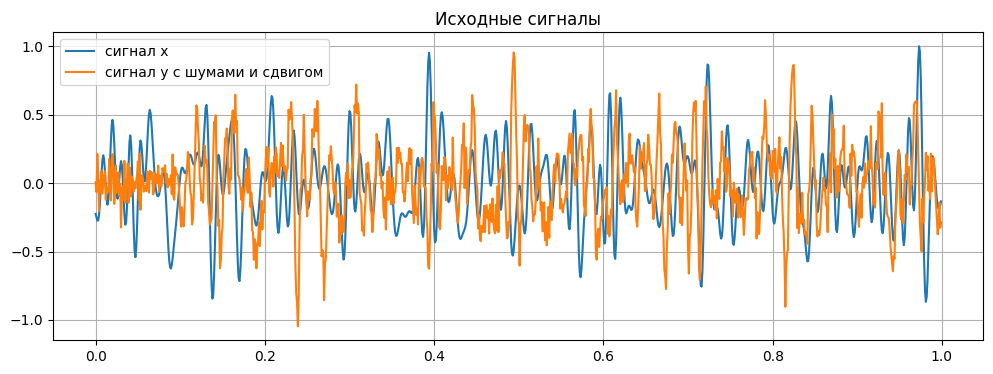

delay_est для первого случая (c шумом = 0.1) =  -100
delay_est для случая (c уровнем шума = 0.0) =  -100
delay_est для случая (c уровнем шума = 0.1) =  -100
delay_est для случая (c уровнем шума = 0.2) =  -100
delay_est для случая (c уровнем шума = 0.3) =  -100
delay_est для случая (c уровнем шума = 0.4) =  -100
delay_est для случая (c уровнем шума = 0.5) =  -100
delay_est для случая (c уровнем шума = 0.6) =  -100
delay_est для случая (c уровнем шума = 0.7) =  -100
delay_est для случая (c уровнем шума = 0.8) =  -100
delay_est для случая (c уровнем шума = 0.9) =  -100
delay_est для случая (c уровнем шума = 1.0) =  -100
delay_est для случая (c уровнем шума = 1.1) =  -100
delay_est для случая (c уровнем шума = 1.2) =  -101
delay_est для случая (c уровнем шума = 1.3) =  -99
delay_est для случая (c уровнем шума = 1.4) =  -100
delay_est для случая (c уровнем шума = 1.5) =  -100
delay_est для случая (c уровнем шума = 1.6) =  -99
delay_est для случая (c уровнем шума = 1.7) =  -100
delay_est для

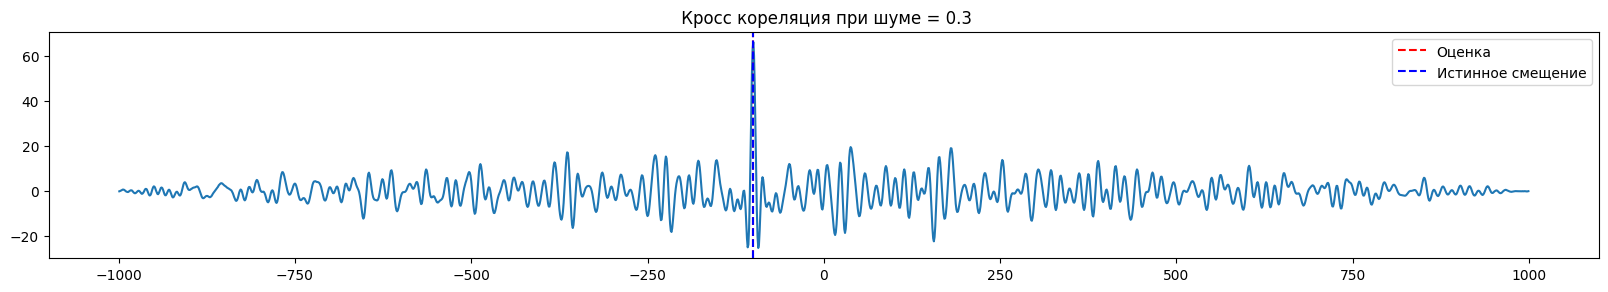

delay_est для случая (c уровнем шума = 2.0) =  311
Истинная задержка - 100


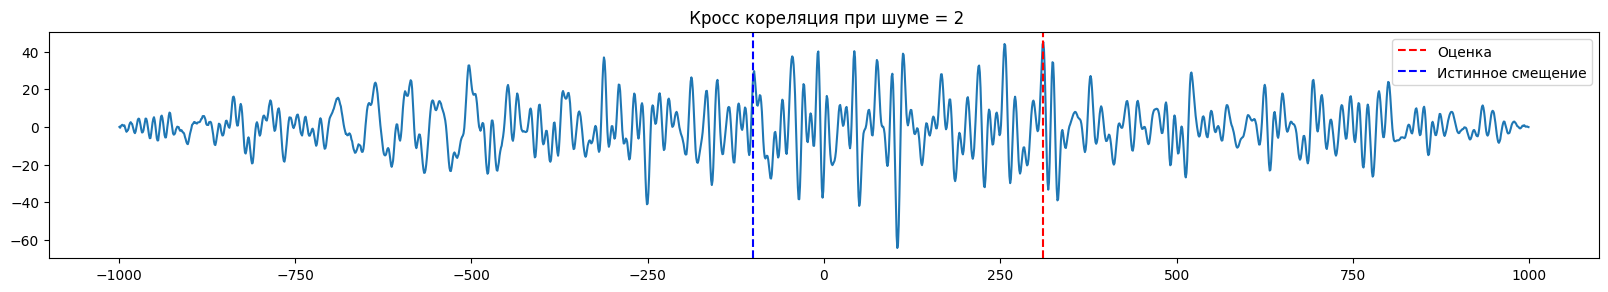

In [18]:
np.random.seed(42)

fs = 1000
t = np.arange(0, 1, 1 / fs)

freq_arr = np.random.uniform(10, 100, 100)
A_arr = np.random.uniform(0.5, 1.5, 100)
phase_arr = np.random.uniform(0, 2 * np.pi, 100)

x = np.zeros_like(t)
for i in range(100):
    x += A_arr[i] * np.sin(2*np.pi*freq_arr[i]*t + phase_arr[i])
x/= np.max(np.abs(x))

delay = 100
noise_level = 0.1
#rand_arr = np.random.randn(len(x))
noise_arr = noise_level * np.random.randn(len(x))

y = np.zeros_like(t)
y[delay:] = x[:-delay]
y += noise_arr
# y /= np.max(np.abs(y))
# убрал нормализациб y

plt.title('Исходные сигналы')
plt.plot(t, x, label = 'сигнал x')
plt.plot(t, y, label = 'сигнал y с шумами и сдвигом')
plt.xlim = (0, 1)
plt.ylim = (-1,1)
plt.grid(True)
plt.legend()
plt.show()

corr = np.correlate(x, y, mode = 'full')
delay_est = np.argmax(corr) - (len(x)-1)
print('delay_est для первого случая (c шумом = 0.1) = ', delay_est)

for j in np.arange(0, 2.1, 0.1):
  noise_level = j
  noise_arr = noise_level * np.random.randn(len(x))

  y = np.zeros_like(t)
  y[delay:] = x[:-delay]
  y += noise_arr
  # y /= np.max(np.abs(y))

  corr = np.correlate(x, y, mode = 'full')
  delay_est = np.argmax(corr) - (len(x)-1)
  print(f'delay_est для случая (c уровнем шума = {j:.1f}) = ', delay_est)


noise_arr = 3 * np.random.randn(len(x))

y = np.zeros_like(t)
y[delay:] = x[:-delay]
y += noise_arr
# y /= np.max(np.abs(y))

corr = np.correlate(x, y, mode = 'full')
delay_est = np.argmax(corr) - (len(x)-1)
print(f'delay_est для случая (c уровнем шума = {3:.1f}) = ', delay_est)


print('\n\n')
def building_plot(noise_level, index_subplot):
  noise_arr = noise_level * np.random.randn(len(x))
  y = np.zeros_like(t)
  y[delay:] = x[:-delay]
  y += noise_arr
  # y /= np.max(np.abs(y))

  corr = np.correlate(x, y, mode = 'full')
  delay_est = np.argmax(corr) - (len(x)-1)
  print(f'delay_est для случая (c уровнем шума = {noise_level:.1f}) = ', delay_est)
  print(f'Истинная задержка - {delay}')

  tmp = np.arange(-len(x) + 1, len(x)) #идея сдвига украдена у
  plt.figure(figsize=(20, 10))
  plt.subplot(3,1,index_subplot)
  plt.title(f' Кросс кореляция при шуме = {noise_level}')
  plt.plot(tmp, corr)
  plt.axvline(delay_est, color='r', linestyle='--', label='Оценка')
  plt.axvline(-delay, color='b', linestyle='--', label='Истинное смещение')
  plt.legend()
  plt.show()

building_plot(0.3, 1)
building_plot(2, 2)

**Вопросы:**
- Как зависит точность оценки задержки от уровня шума? При каком уровне шума вычисленная задержка отличается от истинной более чем на 10%? При каком уровне шума вычисленная задержка становится практически неотличима от `0`?
- Почему при высоком уровне шума могут появляться ложные пики?

1. Очевидно, при увеличении уровня шума, точность задержки должна уменьшаться. На последнем графике показан случай со срывом, при уровне шума = 2, хотя первичные проверки на интервале от 0 до 2 не давали срывов. Так же в списке проверок я добавил проверку при уровне шума = 3, которая дала существенную ошибку(отличие ожидаемого и полученного результата в полтора раза). На малых же значениях уровня шума(до 1.0) ошибок вовсе не возникало. Исходя из этого, логично предположить, что низкий уровень шума (до 1.2-1.5 в моем случае) будет давать малые/сопоставимые с 0 ошибки.
2. При больших уровнях шум становится сопоставим с сигналом, и может быть похож с искомым пиком.


## Задание 4. Обнаружение шаблона в зашумлённом сигнале

### Цель
Найти местоположение сигнала, имеющего форму гауссова импульса, модулированного синусоидой, в смеси с шумом. Исследовать влияние отношения сигнал/шум на точность обнаружения.

### Задание
1. Создайте шаблон `template` – произведение гауссовой огибающей (σ=100 отсчётов) на синусоиду частотой 20 Гц (при fs=1000 Гц). Длина шаблона примерно 6σ.
2. Создайте длинный сигнал `long_signal` длиной 2000 отсчётов, состоящий из:
   - случайного сигнала (шума), созданного с помощью `numpy.random.randn()` с единичной амплитудой,
   - вставленного в случайную позицию шаблона, умноженного на амплитуду `A` (например, 2).
3. Используйте кросс-корреляцию `np.correlate(long_signal, template, mode='valid')` для поиска позиции шаблона. Найдите индекс максимума корреляции.
4. Повторите эксперимент для разных отношений сигнал/шум (SNR), варьируя амплитуду шаблона от 0.2 до 5.
5. Для одного значения SNR (например, 1) визуализируйте: исходный длинный сигнал, шаблон, результат кросс-корреляции с отмеченным пиком.

Результат Кросс-Корреляции: 413
Истинное местонахождение: 413
Результат совпадает с ожидаемым



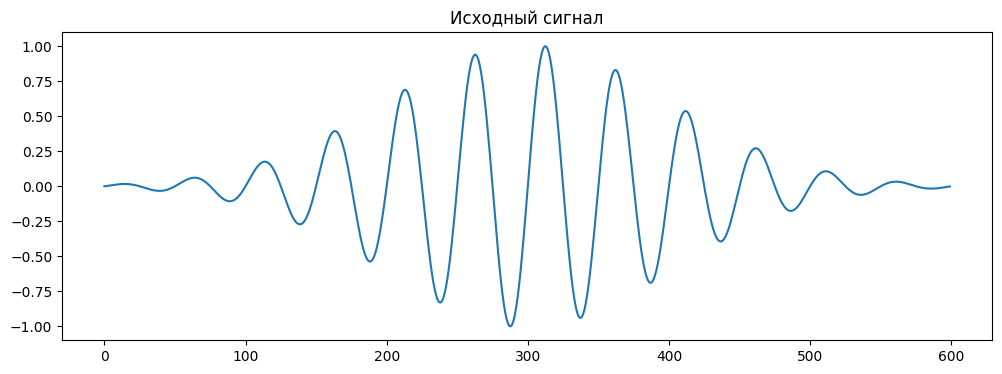

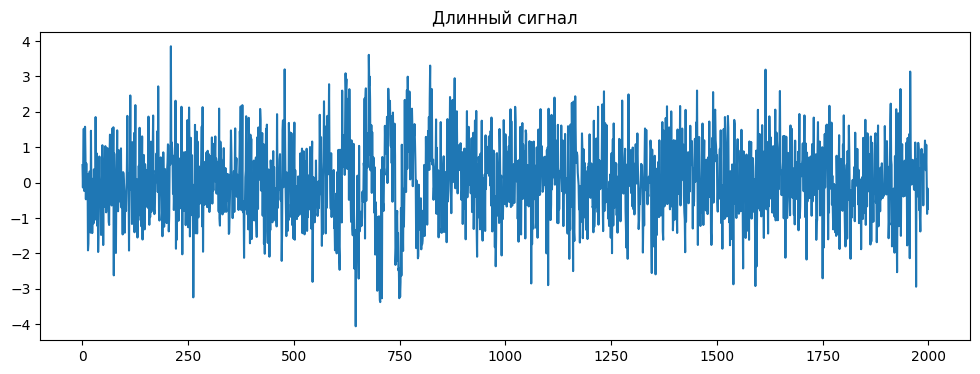

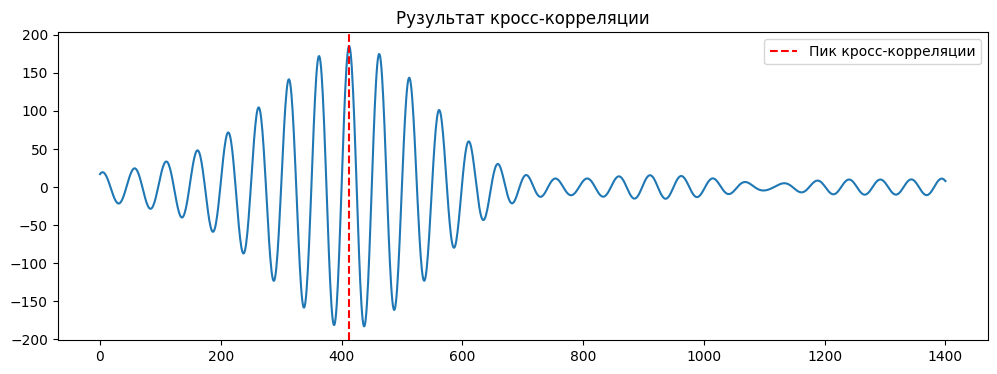

SNR = 0.2
Результат Кросс-Корреляции: 783
Истинное местонахождение: 731
SNR = 0.4
Результат Кросс-Корреляции: 871
Истинное местонахождение: 819
SNR = 0.6000000000000001
Результат Кросс-Корреляции: 816
Истинное местонахождение: 818
SNR = 0.8
Результат Кросс-Корреляции: 982
Истинное местонахождение: 982
SNR = 1.0
Результат Кросс-Корреляции: 42
Истинное местонахождение: 41
SNR = 1.2
Результат Кросс-Корреляции: 551
Истинное местонахождение: 551
SNR = 1.4000000000000001
Результат Кросс-Корреляции: 465
Истинное местонахождение: 465
SNR = 1.6
Результат Кросс-Корреляции: 720
Истинное местонахождение: 721
SNR = 1.8
Результат Кросс-Корреляции: 1299
Истинное местонахождение: 1299
SNR = 2.0
Результат Кросс-Корреляции: 824
Истинное местонахождение: 824
SNR = 2.2
Результат Кросс-Корреляции: 1243
Истинное местонахождение: 1243
SNR = 2.4000000000000004
Результат Кросс-Корреляции: 71
Истинное местонахождение: 71
SNR = 2.6000000000000005
Результат Кросс-Корреляции: 1104
Истинное местонахождение: 1104
SN

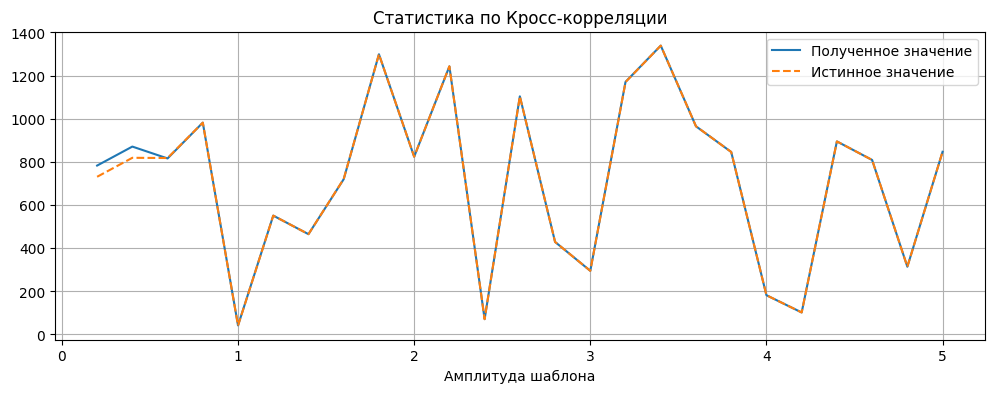

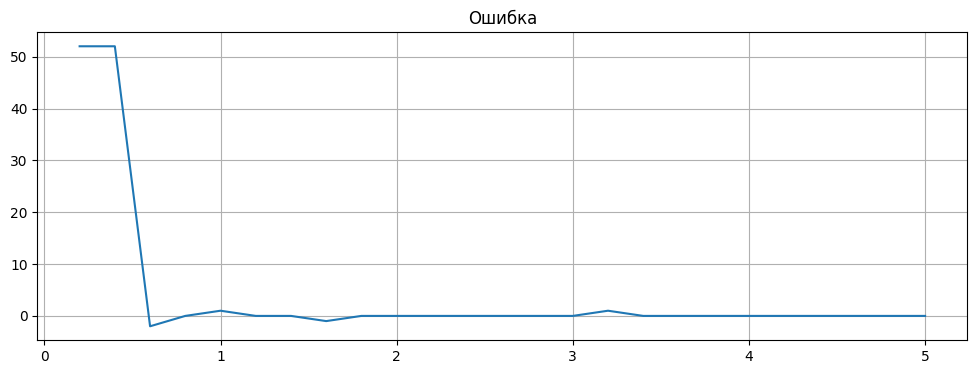

In [19]:
np.random.seed(42)

def build_template(A):
  fs = 1000
  sigma = 100
  d = 20
  L = 6 * sigma
  t = np.arange(-L//2, L//2)
  phase = 0
  result = np.exp(- t**2 / (2 * sigma **2)) * A * np.sin(2* np.pi * d * t /fs + phase)
  return result / np.max(result)


A = 1
template = build_template(A)

fs_long = 2000
long_signal =  np.random.randn(fs_long)

rand_num = np.random.randint(0, fs_long - len(template))

A_long = 2
long_signal[rand_num:rand_num + len(template)] += A_long * template


corr = np.correlate(long_signal, template, mode = 'valid')
idx = np.argmax(corr)

print(f'Результат Кросс-Корреляции: {idx}')
print(f'Истинное местонахождение: {rand_num}')

if idx == rand_num :
  print('Результат совпадает с ожидаемым')
else:
  print('Результат не совпадает с ожидаемым')
print('')

plt.title('Исходный сигнал')
plt.plot(np.arange(len(template)), template)
plt.show()

plt.title('Длинный сигнал')
plt.plot(np.arange(fs_long), long_signal)
plt.show()

plt.title('Рузультат кросс-корреляции')
plt.plot(np.arange(len(corr)), corr)
plt.axvline(idx, color='r', linestyle='--', label='Пик кросс-корреляции')
plt.legend()
plt.show()



predict_value = []
true_value = []
for i in np.arange(0.2, 5.2, 0.2):
  print(f'SNR = {i}')
  template = build_template(1)
  fs_long = 2000
  long_signal =  np.random.randn(fs_long)

  rand_num = np.random.randint(0, fs_long - len(template))

  long_signal[rand_num:rand_num + len(template)] += i * template


  corr = np.correlate(long_signal, template, mode = 'valid')
  idx = np.argmax(corr)

  predict_value.append(idx)
  true_value.append(rand_num)

  print(f'Результат Кросс-Корреляции: {idx}')
  print(f'Истинное местонахождение: {rand_num}')

plt.title('Статистика по Кросс-корреляции')
plt.plot( np.arange(0.2, 5.2, 0.2), predict_value, label = 'Полученное значение')
plt.plot( np.arange(0.2, 5.2, 0.2), true_value, linestyle='--',  label = 'Истинное значение')
plt.xlabel('Амплитуда шаблона')
plt.legend()
plt.grid(True)
plt.show()


error = error = np.array(predict_value) - np.array(true_value)
plt.title('Ошибка')
plt.plot( np.arange(0.2, 5.2, 0.2), error)
plt.grid(True)
plt.show()

**Вопросы:**
- При каком SNR результаты измерения резко ухудшаются?

При малом SNR <= 0.6 результаты измерений резко ухудшаются

## Задание 5. Поиск фрагмента в реальном аудиосигнале

### Цель
Применить кросс-корреляцию для нахождения заданного фрагмента в аудиофайле. Фрагмент и основной файл предоставлены (студентам нужно будет загрузить их).

### Задание
1. Загрузите аудиофайл `full_audio.wav` и фрагмент `fragment.wav`. Используйте `scipy.io.wavfile.read`.
2. Вычислите кросс-корреляцию между полным сигналом и фрагментом.
3. Найдите позицию максимального значения корреляции и определите временное смещение (в отсчётах и в секундах).
4. Постройте график кросс-корреляции и отметьте найденный пик.
5. Вырежьте из полного сигнала участок, соответствующий найденной позиции, и прослушайте его (используйте `Audio`). Убедитесь, что он совпадает с фрагментом.

In [20]:
# Загружаем файл и сохраняем под именем audio.wav
!wget -O full_audio.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/full_audio.wav"
!wget -O fragment.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/fragment.wav"

--2026-04-12 21:24:44--  https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/full_audio.wav
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/full_audio.wav [following]
--2026-04-12 21:24:45--  https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/full_audio.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6990446 (6.7M) [audio/wav]
Saving to: ‘full_audio.wav’

full_audio.wav      100%[===================>]   6.67M  --.-KB/s    in 0.04s   

2026-04-12 21:24:46 (176 MB/s) - ‘full_audio.wav’ saved [6990446/69

44100 44100
(873764, 2) (56401, 2)
(873764,) (56401,)


/tmp/ipykernel_149485/210547704.py:5: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_full, full_audio = wavfile.read("full_audio.wav")
/tmp/ipykernel_149485/210547704.py:6: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_frag, fragment = wavfile.read("fragment.wav")


Смещение (по отсчетам): 279235
Смещение в секундах: 6.331859410430839


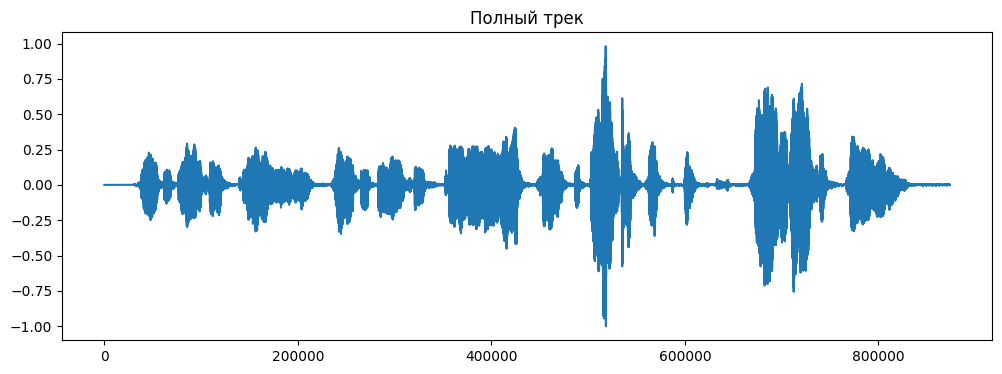

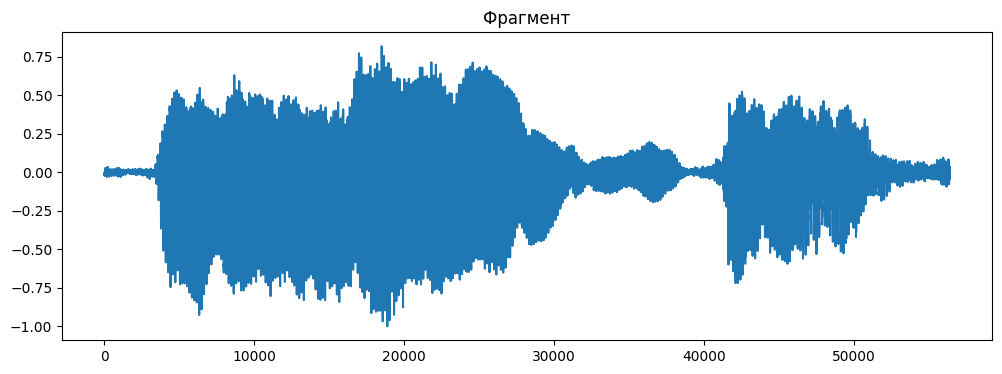

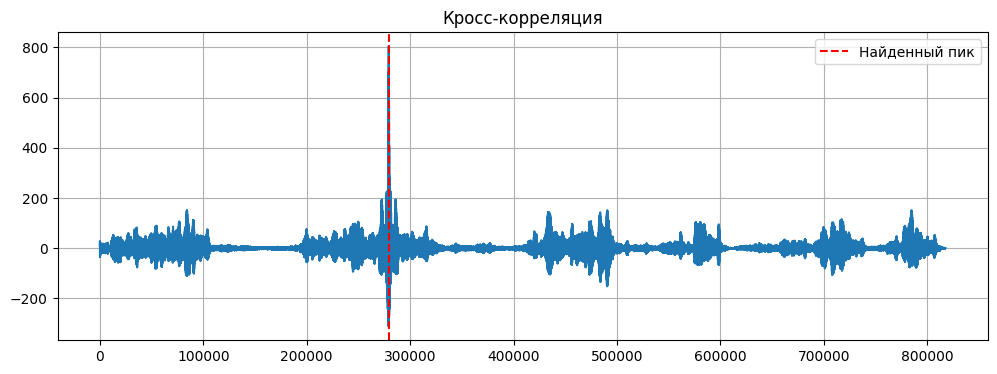

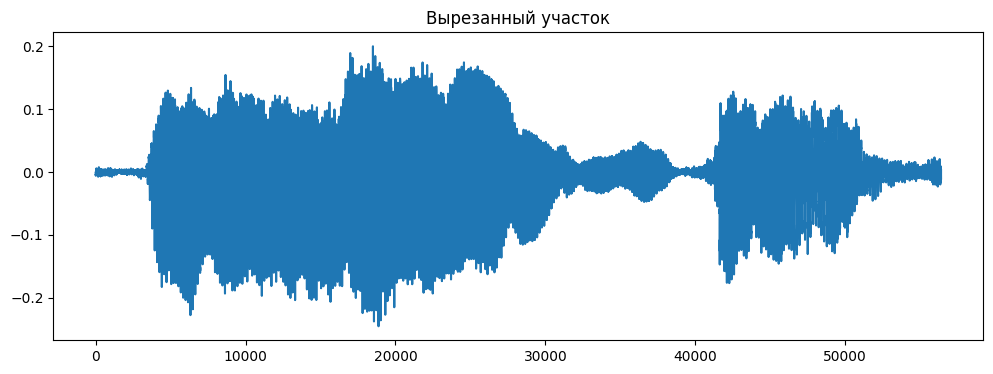

Найденный участок:


Оригинальный фрагмент:


In [21]:
# Этот звук просто имба
from scipy.io import wavfile
from IPython.display import Audio, display

fs_full, full_audio = wavfile.read("full_audio.wav")
fs_frag, fragment = wavfile.read("fragment.wav")

print(fs_full, fs_frag)
print(full_audio.shape, fragment.shape) # чек на стерео

full_audio = full_audio[:, 0] # перевод в моно
fragment = fragment[:, 0]

print(full_audio.shape, fragment.shape) # чек на стерео

full_audio = full_audio / np.max(np.abs(full_audio))
fragment = fragment / np.max(np.abs(fragment))

corr = np.correlate(full_audio, fragment, mode='valid')
idx = np.argmax(corr)

time_sec = idx / fs_full

print("Смещение (по отсчетам):", idx)
print("Смещение в секундах:", time_sec)

plt.title('Полный трек')
plt.plot(full_audio)
plt.show()
plt.title('Фрагмент')
plt.plot(fragment)
plt.show()

plt.plot(corr)
plt.axvline(idx, color='r', linestyle='--', label='Найденный пик')
plt.title("Кросс-корреляция")
plt.legend()
plt.grid(True)
plt.show()

found = full_audio[idx : idx + len(fragment)]
plt.title('Вырезанный участок')
plt.plot(found)
plt.show()

print("Найденный участок:")
display(Audio(found, rate=fs_full)) #only "AUDIO" ломает вывод одного из плееров

print("Оригинальный фрагмент:")
display(Audio(fragment, rate=fs_full))


**Вопросы:**
- Почему перед вычислением корреляции сигналы следует нормализовать?
- Сколько раз в сигнале встречается вырезанное во фрагменте слово? Удаётся ли с помощью корреляционного анализа определить его во всех случаях? Возникают ли ложные максимумы?
- Что будет, если фрагмент не содержится в полном сигнале? Как это отразится на корреляции?

1. Нормализация позволяет сравнивать форму сигнала, а не амплитуду. Без нормализации громкий звук может дать больший численный результат из-за его амплитуды и тем самым по ошибке будет принят за амплитуду.
2. 4 раза. Думаю, нет. Если фрагменты демки похожи, содержат шумы, или имеют сильно сжимающий формат хранения
(например mp3), корреляционный анализ может не дать желаемого результата. В данном примере ложные максимумы мною не обнаружены, но ими могли быть частоповторяющиеся фразы.
3. Будет выбран случайный фрагмент, результат которого наибольшим образом походит на искомый сигнал.